<a href="https://colab.research.google.com/github/ashorinajufan/KUMPULAN-TUGAS-DATA-MINING-/blob/main/UTS_DATA_MINING_184.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PENDAHULUAN

Dalam industri pembuatan wine, penilaian kualitas produk sering kali bergantung pada uji pencicipan oleh pakar yang bersifat subjektif, memakan biaya, dan membutuhkan waktu yang lama. Untuk mengatasi kendala tersebut, proyek ini bertujuan untuk membangun sebuah sistem prediksi berbasis Machine Learning yang objektif. Sistem ini dirancang untuk memprediksi kelas kualitas wine (dalam skala 3 hingga 8) berdasarkan 11 fitur fisikokimianya, seperti kadar alkohol, pH, keasaman, dan residu gula.

Tantangan utama dalam analisis dataset ini adalah kondisi ketidakseimbangan kelas (extreme class imbalance) di mana wine kualitas menengah mendominasi, serta tingginya variasi data yang menghasilkan banyak nilai pencilan (outliers). Oleh karena itu, pendekatan analitik dalam proyek ini berfokus pada penggunaan algoritma XGBoost Classifier sebuah metode ensemble learning berbasis pohon keputusan yang kokoh terhadap data ekstrem dipadukan dengan teknik pembobotan kelas (sample weights). Pendekatan ini dipilih untuk membangun model yang stabil dan general tanpa harus memanipulasi, memotong, atau merusak integritas kumpulan data yang asli.

# IMPORT LIBRARY

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import xgboost as xgb
import joblib

In [3]:
data_training = pd.read_csv('data_training.csv')
data_testing = pd.read_csv('data_testing.csv')

**Memisahkan Fitur (X) dan Target (y) pada Data Latih**

Kode ini membelah tabel data_training menjadi dua bagian. Kolom quality dipisahkan dan dimasukkan ke variabel y_train_full. Sisa kolom lainnya dimasukkan ke variabel X_train_full. Di saat yang sama, kode drop memastikan kolom Id dan quality dibuang dari kelompok X.

In [4]:
if 'Id' in data_training.columns:
    X_train_full = data_training.drop(columns=['Id', 'quality'])
else:
    X_train_full = data_training.drop(columns=['quality'])
y_train_full = data_training['quality']

Sama seperti di atas, kode ini membuang kolom Id dari data yang akan dites (X_test). Namun, sebelum dibuang, nomor-nomor Id tersebut "diselamatkan" dulu ke dalam variabel test_ids. Jika ternyata dari awal file-nya tidak punya kolom Id, fungsi np.arange akan membuatkan nomor urut otomatis.

In [5]:
if 'Id' in data_testing.columns:
    test_ids = data_testing['Id']
    X_test = data_testing.drop(columns=['Id'])
else:
    test_ids = np.arange(1, len(data_testing) + 1)
    X_test = data_testing.copy()

# Exploratory Data Analysis (EDA)

In [6]:
sns.set_theme(style="whitegrid")
fitur_numerik = X_train_full.columns

1. **Countplot**

Grafik ini menghitung dan menampilkan jumlah sampel data (baris) untuk setiap angka kategori kualitas wine, mulai dari kualitas 3 hingga 8.

/tmp/ipykernel_4591/4261155801.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='quality', data=data_training, palette='viridis')


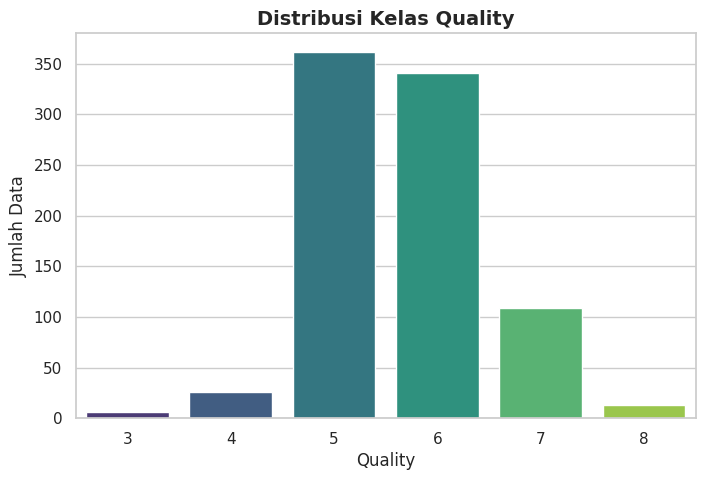

In [7]:
plt.figure(figsize=(8, 5))
sns.countplot(x='quality', data=data_training, palette='viridis')
plt.title('Distribusi Kelas Quality', fontsize=14, fontweight='bold')
plt.xlabel('Quality')
plt.ylabel('Jumlah Data')
plt.show()

Grafik ini adalah bukti visual paling kuat bahwa dataset mengalami Extreme Class Imbalance (Ketidakseimbangan Kelas Ekstrem). Kualitas 5 dan 6 mendominasi hampir keseluruhan data (berkisar di angka ratusan). Sebaliknya, kualitas 3 dan 8 nyaris rata dengan batas.

2. **Grid of Histogram**

Memvisualisasikan sebaran frekuensi (distribusi) dari setiap fitur kimiawi secara terpisah. Sumbu-X adalah nilai kadar kimia, dan sumbu-Y adalah jumlah wine yang memiliki kadar tersebut.

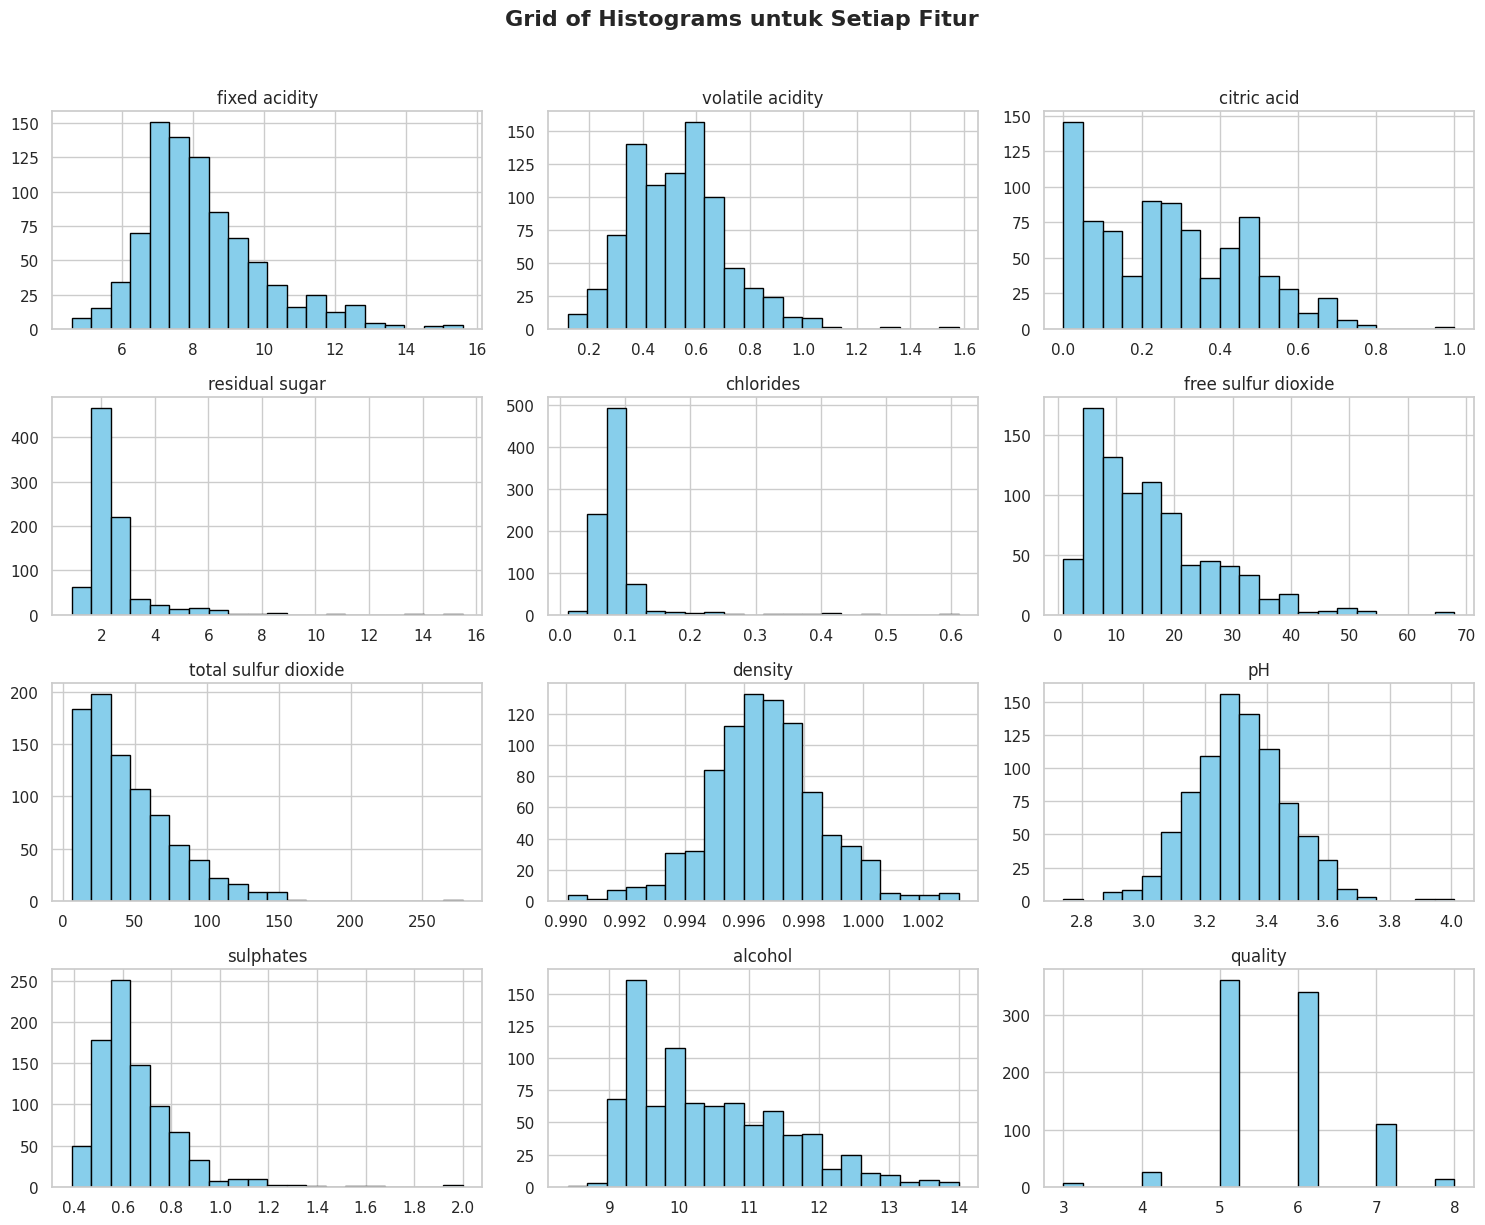

In [8]:
data_training.drop(columns=['Id'], errors='ignore').hist(bins=20, figsize=(15, 12), color='skyblue', edgecolor='black')
plt.suptitle('Grid of Histograms untuk Setiap Fitur', y=1.02, fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

Kita bisa melihat bahwa hampir tidak ada fitur yang terdistribusi secara simetris sempurna di tengah. Banyak fitur seperti residual sugar, chlorides, dan sulphates memiliki bentuk Right-Skewed (menjulur tajam ke kanan). Artinya, mayoritas wine memiliki kadar gula, klorida, dan sulfat yang sangat rendah, tetapi ada sebagian kecil wine anomali yang kadarnya melambung sangat tinggi.

3. **Histograms with KDE (Kernel Density Estimation)**

Ini adalah versi yang lebih halus dari histogram sebelumnya. Garis melengkung (KDE) bertugas mengestimasi probabilitas kepadatan data secara kontinu, tanpa terpotong oleh kotak-kotak batang.

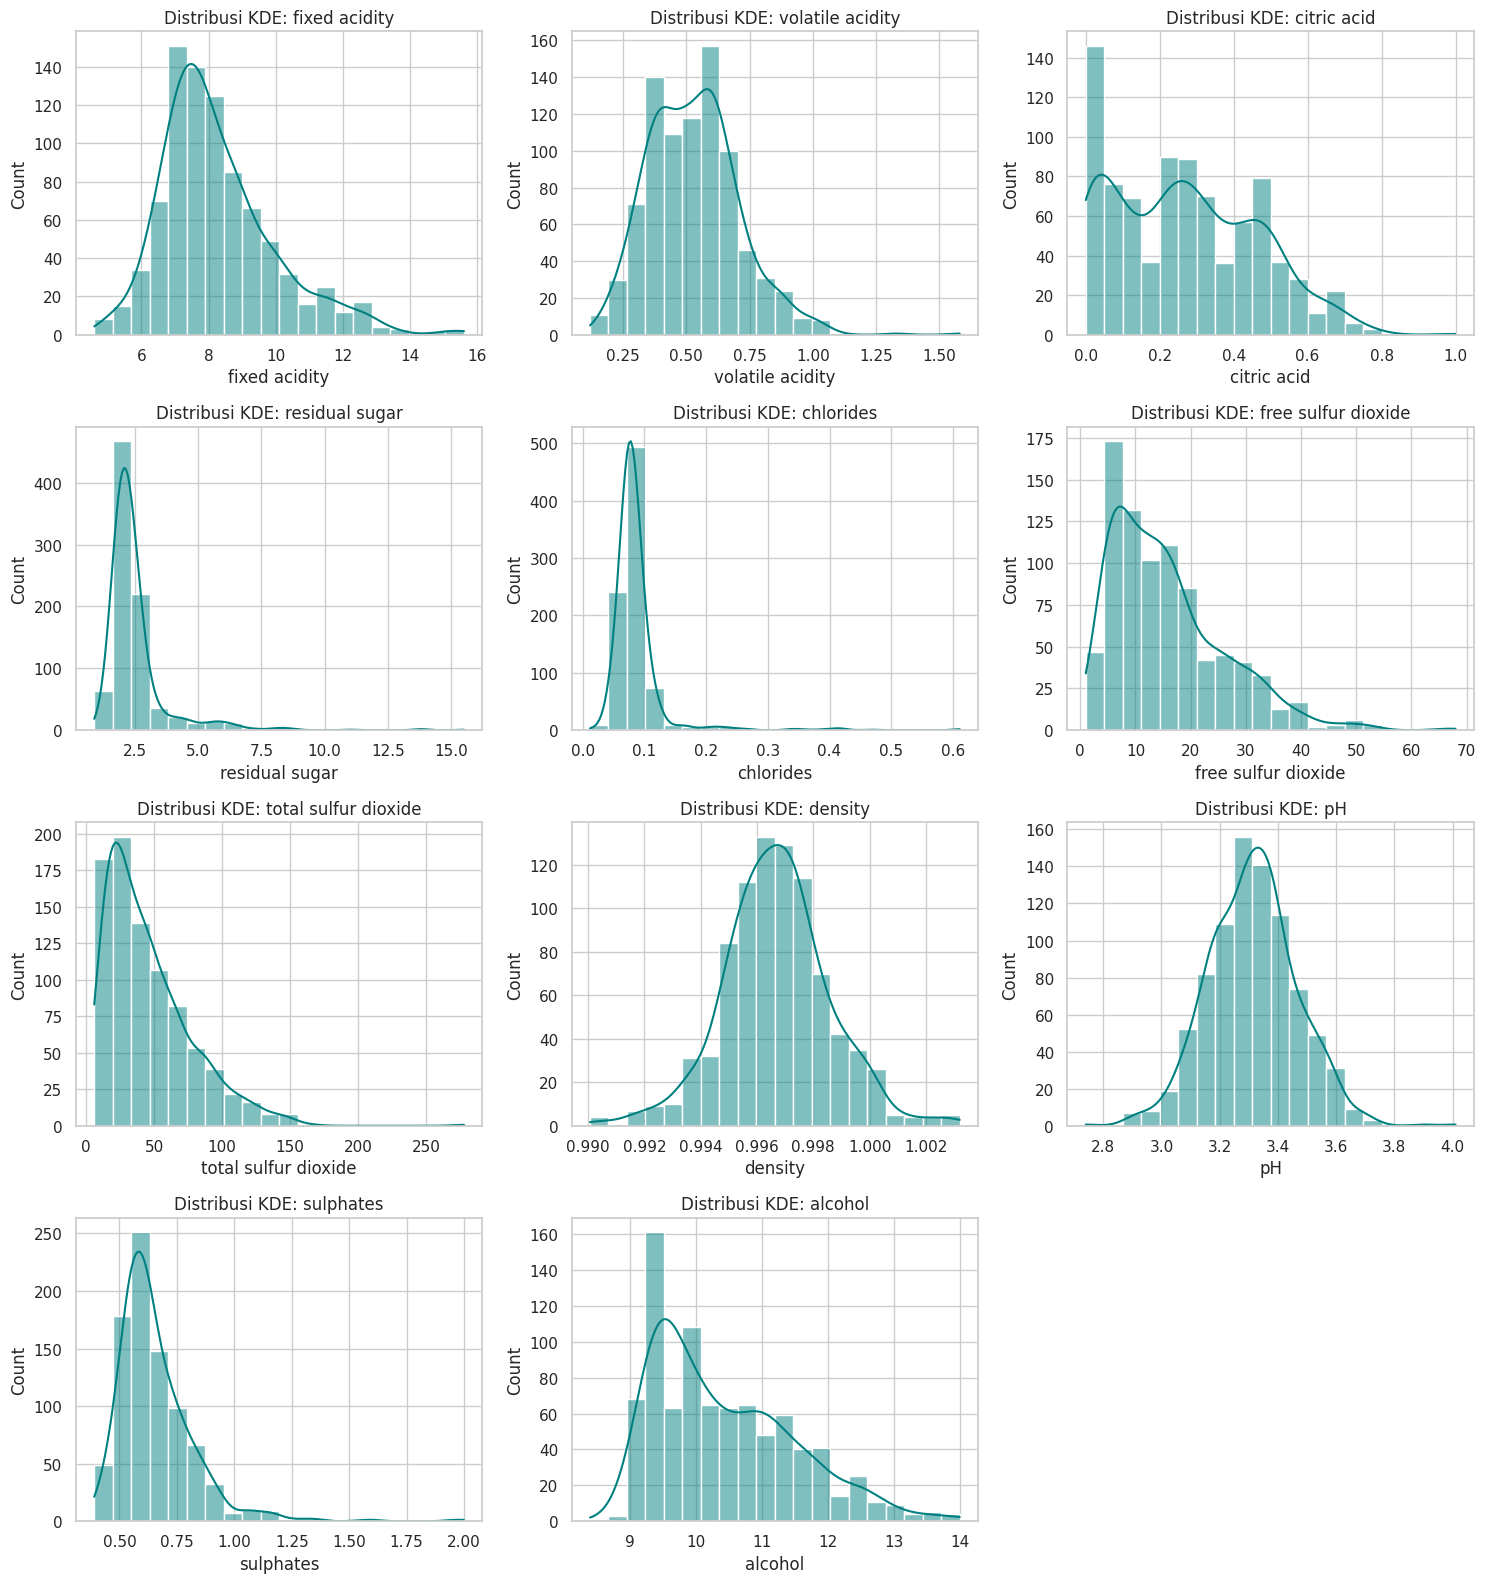

In [9]:
import math
cols_count = len(fitur_numerik)
rows_count = math.ceil(cols_count / 3)

plt.figure(figsize=(15, rows_count * 4))
for i, col in enumerate(fitur_numerik, 1):
    plt.subplot(rows_count, 3, i)
    sns.histplot(data_training[col], kde=True, color='teal', bins=20)
    plt.title(f'Distribusi KDE: {col}')
plt.tight_layout()
plt.show()

Kurva ini membantu kita melihat "puncak" dari data kimiawi wine. Dari sini terlihat jelas bahwa fitur pH dan density memiliki bentuk paling mendekati "distribusi normal" (lonceng simetris sempurna). Sementara fitur lain puncaknya cenderung miring ke kiri.

4. **Boxplot**

Menunjukkan 5 ringkasan statistik (nilai minimum, kuartil 1, median, kuartil 3, nilai maksimum) dari setiap fitur kimia yang dipisahkan berdasarkan kelas kualitas. Lingkaran kecil di luar garis adalah outliers (data pencilan/nyeleneh).

/tmp/ipykernel_4591/2972275325.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='quality', y=col, data=data_training, palette='Set2')
/tmp/ipykernel_4591/2972275325.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='quality', y=col, data=data_training, palette='Set2')
/tmp/ipykernel_4591/2972275325.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='quality', y=col, data=data_training, palette='Set2')
/tmp/ipykernel_4591/2972275325.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed 

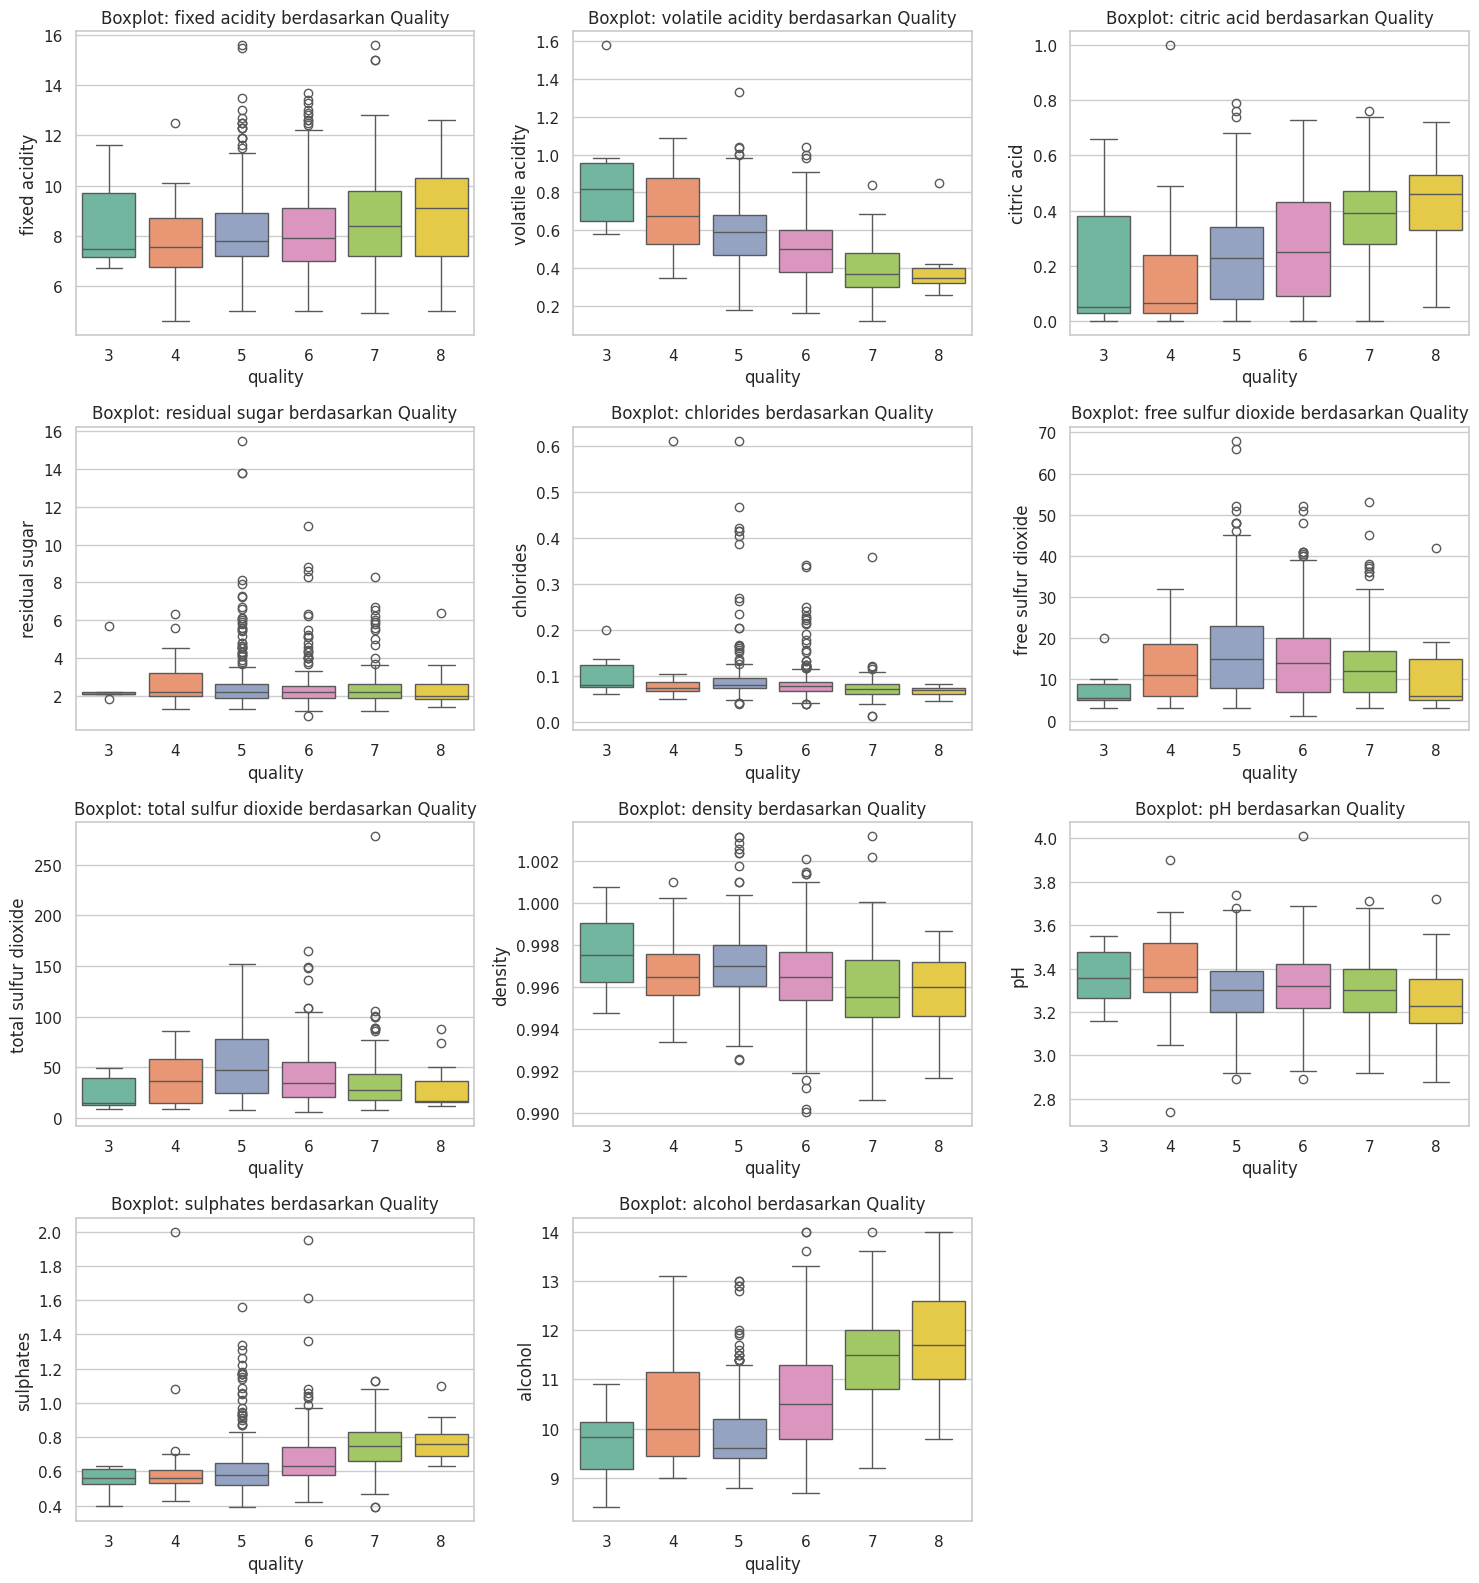

In [10]:
plt.figure(figsize=(15, rows_count * 4))
for i, col in enumerate(fitur_numerik, 1):
    plt.subplot(rows_count, 3, i)
    sns.boxplot(x='quality', y=col, data=data_training, palette='Set2')
    plt.title(f'Boxplot: {col} berdasarkan Quality')
plt.tight_layout()
plt.show()

perhatikan kotak pada fitur alcohol: terlihat jelas bahwa semakin tinggi kualitas wine (ke arah kanan), median alkoholnya (garis tengah di dalam kotak) cenderung semakin naik. Selain itu, banyaknya titik-titik lingkaran (outliers) pada residual sugar dan chlorides menunjukkan bahwa banyak data ekstrem.

5. **Heatmap Correlation**

Sebuah matriks yang menunjukkan seberapa kuat hubungan antar-variabel. Nilai berkisar dari -1 hingga 1. Warna merah berarti korelasi positif (sejalan), warna biru berarti korelasi negatif (berlawanan), dan warna pucat berarti tidak ada hubungan.

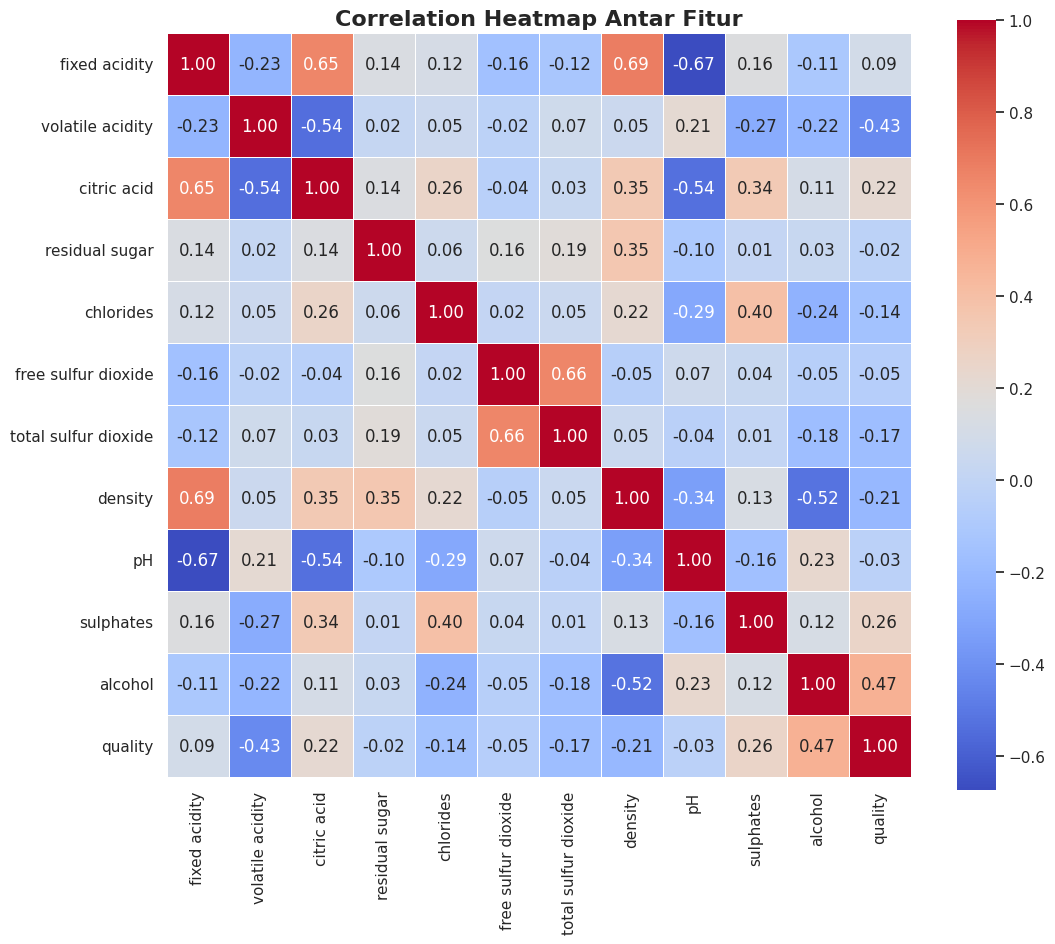

In [11]:
plt.figure(figsize=(12, 10))
korelasi = data_training.drop(columns=['Id'], errors='ignore').corr()
sns.heatmap(korelasi, annot=True, fmt=".2f", cmap='coolwarm', square=True, linewidths=.5)
plt.title('Correlation Heatmap Antar Fitur', fontsize=16, fontweight='bold')
plt.show()

Lihat baris/kolom quality. Fitur alcohol memiliki warna merah paling pekat (0.47), mengartikan alkohol adalah faktor pendorong kualitas tertinggi (makin tinggi alkohol, makin bagus winenya). Sebaliknya, volatile acidity berwarna biru pekat (-0.43), yang berarti semakin tinggi asam volatil, kualitas wine cenderung menurun. Ini membantu kita memahami fitur mana yang diprioritaskan oleh model saat menebak.

6. **Pairplot**

Memplot hubungan dua arah antar 4 fitur yang paling kuat korelasinya terhadap kualitas, dengan titik-titiknya diwarnai berdasarkan label kelas kualitas wine (3, 4, 5, 6, 7, 8).

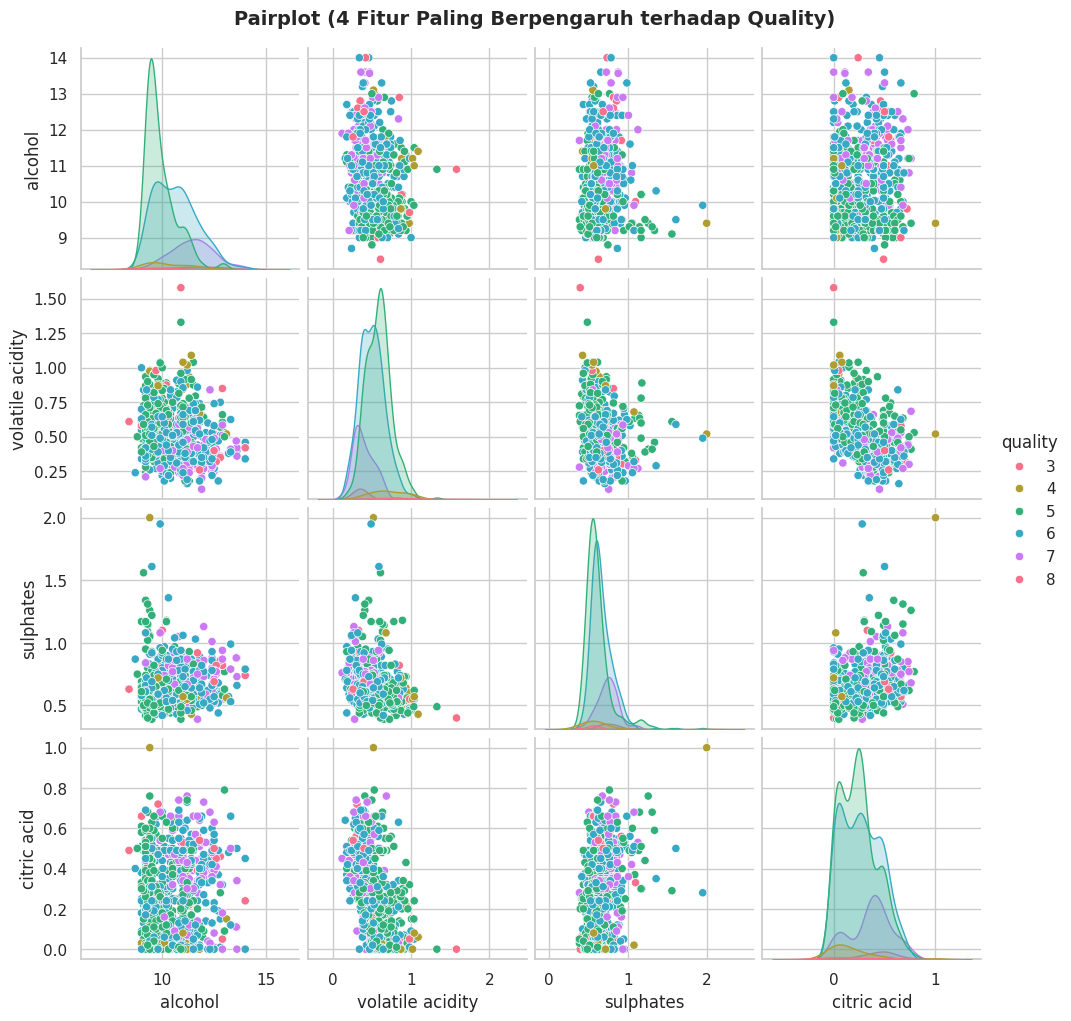

In [12]:
korelasi_tertinggi = korelasi['quality'].abs().sort_values(ascending=False).index[1:5] # Ambil top 4 selain quality itu sendiri
fitur_pairplot = list(korelasi_tertinggi) + ['quality']

sns.pairplot(data_training[fitur_pairplot], hue='quality', palette='husl')
plt.suptitle('Pairplot (4 Fitur Paling Berpengaruh terhadap Quality)', y=1.02, fontsize=14, fontweight='bold')
plt.show()

Visualisasi ini adalah jawaban kenapa akurasi model sulit menembus angka tinggi. Perhatikan sebaran titiknya; warna-warna (kelas wine) tampak sangat menumpuk dan tercampur aduk. Tidak ada satu pun batas pemisah yang jelas antar warna. Karena secara kasat mata fitur-fiturnya tumpang tindih (overlapping), model machine learning pun harus bersusah payah menebak garis pemisahnya.

# PEMBERSIH DATA

In [13]:
data_training.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.3,0.740,0.08,1.7,0.094,10.0,45.0,0.99576,3.24,0.50,9.8,5,1366
1,8.1,0.575,0.22,2.1,0.077,12.0,65.0,0.99670,3.29,0.51,9.2,5,103
2,10.1,0.430,0.40,2.6,0.092,13.0,52.0,0.99834,3.22,0.64,10.0,7,942
3,12.9,0.500,0.55,2.8,0.072,7.0,24.0,1.00012,3.09,0.68,10.9,6,811
4,8.4,0.360,0.32,2.2,0.081,32.0,79.0,0.99640,3.30,0.72,11.0,6,918


In [14]:
data_training.tail()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
852,6.7,1.04,0.08,2.3,0.067,19.0,32.0,0.99648,3.52,0.57,11.0,4,1467
853,8.0,0.39,0.30,1.9,0.074,32.0,84.0,0.99717,3.39,0.61,9.0,5,1533
854,7.4,0.35,0.33,2.4,0.068,9.0,26.0,0.99470,3.36,0.60,11.9,6,1580
855,7.9,0.57,0.31,2.0,0.079,10.0,79.0,0.99677,3.29,0.69,9.5,6,1216
856,7.5,0.52,0.40,2.2,0.060,12.0,20.0,0.99474,3.26,0.64,11.8,6,1575


In [15]:
data_training.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000
mean,8.261960,0.529393,0.267351,2.506184,0.086830,15.782964,45.978413,0.996692,3.313092,0.656709,10.430338,5.653442,813.749125
std,1.701992,0.179162,0.195144,1.293512,0.048721,10.300402,31.692113,0.001901,0.152079,0.167364,1.066971,0.821777,463.807063
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.390000,8.400000,3.000000,0.000000
25%,7.100000,0.395000,0.090000,1.900000,0.070000,7.000000,21.000000,0.995520,3.210000,0.550000,9.500000,5.000000,413.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,14.000000,38.000000,0.996680,3.310000,0.620000,10.200000,6.000000,814.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,63.000000,0.997800,3.400000,0.730000,11.100000,6.000000,1214.000000
max,15.600000,1.580000,1.000000,15.500000,0.611000,68.000000,278.000000,1.003200,4.010000,2.000000,14.000000,8.000000,1597.000000


In [16]:
data_training.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 857 entries, 0 to 856
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         857 non-null    float64
 1   volatile acidity      857 non-null    float64
 2   citric acid           857 non-null    float64
 3   residual sugar        857 non-null    float64
 4   chlorides             857 non-null    float64
 5   free sulfur dioxide   857 non-null    float64
 6   total sulfur dioxide  857 non-null    float64
 7   density               857 non-null    float64
 8   pH                    857 non-null    float64
 9   sulphates             857 non-null    float64
 10  alcohol               857 non-null    float64
 11  quality               857 non-null    int64  
 12  Id                    857 non-null    int64  
dtypes: float64(11), int64(2)
memory usage: 87.2 KB


**CEK MISSING VALUE**

In [17]:
data_training.isnull().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


In [18]:
data_training.isnull().sum().sum()

np.int64(0)

Hasilnya adalah 0 untuk semua kolom. Ini mengonfirmasi temuan kita dari .info() sebelumnya bahwa dataset ini sangat bersih dari data yang hilang. Sehingga bisa langsung melewati tahapan data cleaning seperti imputasi (mengisi data kosong dengan nilai rata-rata/median) atau menghapus baris yang kosong.

**Feature Scaling**

Dilakukan proses scaling menggunakan StandardScaler untuk menyamakan skala antar fitur.

In [19]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_full)
X_test_scaled = scaler.transform(X_test)

**Label Encoder**

Menggunakan LabelEncoder untuk mengubah label quality dari angka (3, 4, 5...) menjadi angka urut yang dimulai dari nol (0, 1, 2...). Karena, Algoritma XGBoost memiliki aturan baku (syarat bawaan) bahwa target untuk klasifikasi multi-kelas harus dimulai dari angka 0.

In [20]:
le = LabelEncoder()
y_train_full_enc = le.fit_transform(y_train_full)

# PEMBUAT DAN EVALUASI MODEL

**Data Latih**

Data latih dipecah lagi dengan fungsi train_test_split dan diberi parameter stratify.





In [21]:
X_tr, X_val, y_tr_enc, y_val_enc = train_test_split(
    X_train_scaled,
    y_train_full_enc,
    test_size=0.2,
    random_state=42,
    stratify=y_train_full_enc
)

Fungsi compute_sample_weight dipanggil untuk menghitung bobot penalti dari kelas minoritas.

In [22]:
bobot_sampel_tr = compute_sample_weight(class_weight='balanced', y=y_tr_enc)

Model dikonfigurasi (max_depth=6, learning_rate=0.1) lalu dilatih (dievaluasi) menggunakan Confusion Matrix. Terakhir, model dilatih ulang dengan 100% data sebelum disimpan dengan format .pkl.


In [23]:
model_xgb = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=len(np.unique(y_train_full_enc)),
    max_depth=6,
    learning_rate=0.1,
    n_estimators=150,
    random_state=42,
    eval_metric='mlogloss'
)

In [24]:
model_xgb.fit(X_tr, y_tr_enc, sample_weight=bobot_sampel_tr)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=150, n_jobs=None, num_class=6, ...)

In [25]:
y_val_pred_enc = model_xgb.predict(X_val)

In [26]:
y_val_asli = le.inverse_transform(y_val_enc)
y_val_pred_asli = le.inverse_transform(y_val_pred_enc)

In [27]:
accuracy = accuracy_score(y_val_asli, y_val_pred_asli)
print(f"\n--- HASIL EVALUASI LOKAL ---")
print(f"Akurasi: {accuracy * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_val_asli, y_val_pred_asli, zero_division=0))


--- HASIL EVALUASI LOKAL ---
Akurasi: 57.56%

Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         5
           5       0.65      0.74      0.69        73
           6       0.55      0.54      0.55        68
           7       0.44      0.32      0.37        22
           8       1.00      0.33      0.50         3

    accuracy                           0.58       172
   macro avg       0.44      0.32      0.35       172
weighted avg       0.57      0.58      0.57       172



Pada dataset yang seimbang, akurasi sangat bisa diandalkan. Namun, pada dataset wine yang sangat imbalanced (kualitas 5 dan 6 mendominasi), akurasi bisa menipu. Model bisa saja mendapat akurasi 57,56% hanya dengan menebak angka 5 dan 6 terus-menerus.

Macro Avg menghitung rata-rata F1-score dengan menganggap semua kelas (mayoritas maupun minoritas) itu sama pentingnya.

**Confusion Matrix**

Visualisasi berbentuk tabel kotak-kotak yang membandingkan sumbu Aktual (kebenaran) dengan sumbu Prediksi (tebakan model).

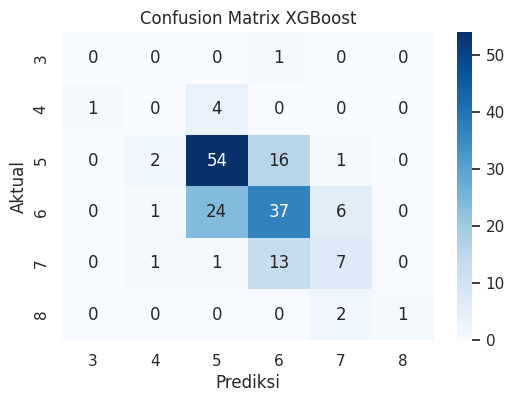

In [28]:
cm = confusion_matrix(y_val_asli, y_val_pred_asli)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix XGBoost')
plt.ylabel('Aktual')
plt.xlabel('Prediksi')
plt.show()

Angka di kotak diagonal utama adalah jumlah tebakan yang benar. Sedangkan angka di luar diagonal adalah error (kesalahan). Dari sini bisa menjelaskan, misalnya: "Model saya kadang kebingungan membedakan wine kualitas 5 dan 6 karena komposisi kimianya yang sangat mirip, terlihat dari tingginya angka salah tebak di persimpangan kotak tersebut.


- Tebakan benarnya cukup tinggi (angka 54 untuk kualitas 5, dan angka 37 untuk kualitas 6).

- Tebakan meleset terbesar terjadi antara wine 5 dan 6. Ada 24 wine kualitas 6 yang disangka kualitas 5, dan 16 wine kualitas 5 yang disangka kualitas 6.

Ini mengonfirmasi bahwa rentang bahan kimia di kualitas menengah sangat mirip, sehingga model memilih menebak di batas yang paling aman. Kolom 3 dan 8 juga terlihat kosong di area tebakan, menegaskan kembali fenomena kehati-hatian model akibat data yang tidak seimbang.


In [29]:
bobot_sampel_full = compute_sample_weight(class_weight='balanced', y=y_train_full_enc)

In [30]:
model_xgb.fit(X_train_scaled, y_train_full_enc, sample_weight=bobot_sampel_full)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=150, n_jobs=None, num_class=6, ...)

Kita kembali memanggil fungsi compute_sample_weight untuk menghitung bobot kelas minoritas, tetapi kali ini diaplikasikan pada 100% data latih (y_train_full_enc). Setelah itu, fungsi .fit() dijalankan kembali menggunakan seluruh data fitur (X_train_scaled) dan labelnya.

**Simpan Model**

Dalam dunia industri, proses melatih model bisa memakan waktu berjam-jam bahkan berhari-hari. Kita tidak mungkin menjalankan kode dari awal setiap kali ingin menebak data wine baru. File .pkl ini adalah bentuk "otak buatan" yang sudah dibekukan. File ini nantinya bisa langsung dipanggil (di-load) oleh aplikasi web atau sistem lain untuk langsung melakukan prediksi dalam hitungan detik.

In [31]:
model_filename = 'model_xgboost_wine.pkl'
joblib.dump(model_xgb, model_filename)
print(f"Model berhasil disimpan sebagai '{model_filename}'")

Model berhasil disimpan sebagai 'model_xgboost_wine.pkl'


# PREDIKSI DATA UJI

Model mengamati bahan kimia dari data uji dan mengeluarkan tebakan kualitasnya. Namun ingat, karena algoritma XGBoost beroperasi dengan angka sandi, hasil dari y_test_pred_enc ini masih berupa deretan angka 0, 1, 2, 3, dan seterusnya.

In [32]:
y_test_pred_enc = model_xgb.predict(X_test_scaled)

Objek LabelEncoder (le) yang sebelumnya digunakan untuk mengubah kualitas wine menjadi angka 0, 1, 2, kini digunakan secara terbalik (inverse_transform) untuk menerjemahkan angka tebakan model kembali menjadi angka kualitas aslinya (misalnya 4, 5, 6, 7, 8).

In [33]:
y_test_pred_final = le.inverse_transform(y_test_pred_enc)

# FINAL SUBMISSION

In [34]:
from google.colab import files

submission_df = pd.DataFrame({
    'Id': test_ids,
    'quality': y_test_pred_final
})
output_filename = 'hasilprediksi_184.csv'
submission_df.to_csv(output_filename, index=False)
files.download(output_filename)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# KESIMPULAN

Berdasarkan hasil prediksi akhir yang dikeluarkan oleh model Machine Learning terhadap data pengujian (testing data), dapat ditarik beberapa kesimpulan mengenai profil kualitas wine sebagai berikut:

1. Dominasi Kualitas Menengah (Standar Rata-Rata):
Secara keseluruhan, hasil tebakan kualitas wine sangat terpusat pada kategori menengah, yaitu kelas 5 dan 6. Hal ini secara langsung mencerminkan realita produksi wine di lapangan, di mana mayoritas produk yang dihasilkan pabrik secara massal memiliki standar kelayakan rata-rata cukup baik untuk dikonsumsi, namun belum mencapai karakteristik wine premium.

2. Kelangkaan Kualitas Ekstrem:
Wine dengan kualitas sangat rendah (kelas 3) maupun kualitas sangat tinggi (kelas 8) muncul dalam jumlah yang sangat langka. Fakta bahwa model memprediksi sangat sedikit (atau bahkan tidak ada) wine di kelas 3 membuktikan bahwa model bekerja secara logis dan berhati-hati. Hal ini menegaskan bahwa menghasilkan wine yang "sempurna" (kualitas 8) atau "benar-benar gagal" (kualitas 3) adalah kejadian yang sangat anomali dan jarang terjadi dalam populasi produksi normal.

3. Faktor Kimia Penentu Kualitas Utama:
Dari analisis fitur yang mendorong hasil prediksi tersebut, kualitas wine terbukti sangat dikendalikan oleh komposisi kimianya. Wine yang diprediksi masuk ke dalam kualitas unggul (kelas 7 dan 8) secara konsisten ditopang oleh kadar alkohol yang lebih tinggi serta minimnya asam volatil (volatile acidity). Sebaliknya, wine yang diprediksi jatuh ke kualitas bawah (kelas 4 atau 5) umumnya memiliki kadar asam asetat yang lebih pekat, yang merusak profil rasanya.

4. Tingkat Realistis dan Reliabilitas Prediksi:
Distribusi tebakan yang dihasilkan oleh model (didominasi kelas menengah dengan sedikit pencilan di ujung) memiliki proporsi yang sangat identik dengan sebaran alami data aslinya. Hal ini menyimpulkan bahwa hasil prediksi yang Anda buat sangat realistis dan dapat diandalkan (reliabel). Model berhasil menerjemahkan pola kimiawi wine menjadi penilaian kualitas yang masuk akal tanpa melakukan tebakan liar pada data yang tumpang tindih.

# REKOMENDASI

Berdasarkan keseluruhan proses pemodelan dan hasil evaluasi prediksi kualitas wine, terdapat beberapa rekomendasi strategis yang dapat diajukan, baik untuk pengembangan sistem di masa depan maupun untuk praktisi di industri wine:

1. Rekomendasi untuk Pengembangan Model (Sisi Data Science)

Pengumpulan Data Terarah (Targeted Data Collection): Tantangan terbesar model ini adalah ketidakseimbangan kelas (imbalance). Disarankan untuk mengumpulkan lebih banyak sampel data fisikokimia untuk wine dengan kualitas sangat rendah (kelas 3 dan 4) dan kualitas sangat tinggi (kelas 8 dan 9). Penambahan data asli pada kelas minoritas akan jauh lebih efektif daripada sekadar menggunakan teknik pembobotan sintetik.

Eksplorasi Feature Engineering: Daripada hanya menggunakan variabel tunggal, pengembangan selanjutnya dapat mencoba membuat variabel baru (fitur sintetik). Contohnya, membuat rasio antara tingkat kemanisan (residual sugar) dengan total keasaman (fixed acidity), atau rasio antara free sulfur dioxide dengan total sulfur dioxide. Kombinasi kimiawi ini berpotensi memberikan pola baru yang lebih mudah dipahami oleh algoritma untuk membedakan kelas menengah yang tumpang tindih.

Penggunaan Teknik Oversampling (SMOTE): Jika pengumpulan data baru tidak memungkinkan, model selanjutnya dapat dieksplorasi menggunakan teknik Synthetic Minority Over-sampling Technique (SMOTE) untuk menciptakan data buatan pada kelas minoritas. Namun, ini harus dilakukan dengan sangat hati-hati agar tidak memicu overfitting.

2. Rekomendasi untuk Praktisi dan Produsen Wine (Sisi Bisnis/Industri)

Pengendalian Ketat pada Asam Volatil: Berdasarkan hasil analisis korelasi, volatile acidity (asam asetat/cuka) adalah "musuh utama" kualitas wine. Produsen harus sangat ketat mengontrol suhu fermentasi dan paparan oksigen untuk mencegah pertumbuhan bakteri yang menyebabkan tingginya asam volatil ini, karena fitur ini secara konsisten menjatuhkan prediksi wine ke kelas bawah (4 dan 5).

Optimalisasi Kadar Alkohol: Model secara konsisten memprediksi wine dengan kadar alkohol yang lebih tinggi ke dalam kategori kualitas unggul (kelas 7 dan 8). Oleh karena itu, produsen dapat berfokus pada teknik pemetikan anggur di tingkat kematangan yang optimal (kadar gula alami tinggi) agar proses fermentasi dapat menghasilkan persentase alkohol yang maksimal secara natural tanpa merusak keseimbangan rasa.